# Candlestick Trend Classifier

End-to-end notebook: data acquisition & labeling methodology, preprocessing, feature interpretation visualizations, model training (MobileNetV2 transfer learning), evaluation, model persistence, and single-datapoint inference verification.

**Task:** classify whether a candlestick chart image visually shows a rising ("Up") or falling ("Down") trend across the candles drawn in the image itself. This is a visual pattern-recognition task, not a forecast -- see Section 1 for why that distinction matters and how the labels were derived.

In [1]:
import sys
sys.path.insert(0, "..")  # so `import src...` resolves from the project root

import numpy as np
from PIL import Image
import glob
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

from src.preprocessing import (
    load_datasets,
    plot_color_channel_dominance,
    plot_edge_detection,
    plot_class_distribution_and_intensity,
)
from src.model import build_model, train_model, evaluate_model, save_model, unfreeze_and_recompile
from src.prediction import predict_image

TRAIN_DIR = "../data/train"
TEST_DIR = "../data/test"
MODEL_PATH = "../models/candlestick_model.keras"

sns.set_theme(style="whitegrid")

## 1. Data Acquisition, Labeling & Preprocessing

### 1.1 Original label, and why it was replaced

The source dataset ([Candlestick Image Data](https://www.kaggle.com/datasets/raimiazeezbabatunde/candle-image-data) by Raimi Azeez Babatunde) ships each image labeled `Up`/`Down` by the sign of the cumulative return over the **5 days after** the candles shown -- a future outcome, not something visible in the image itself.

We trained against that label first and investigated the result rigorously: two-phase MobileNetV2 transfer learning (frozen-backbone head training, then end-to-end fine-tuning at a low learning rate), confirmed the source images were downsampled rather than upsampled (ruling out a resolution bug), and verified label/prediction alignment independently. Result: **test ROC-AUC of 0.436** -- at chance, within noise of 0.5 for a 351-example test set. That's an expected, defensible outcome (predicting future price direction from chart shape alone runs straight into market efficiency), but it does not demonstrate a working classifier.

### 1.2 Relabeling by visual trend

Instead, every image was relabeled by the trend it **visually shows**: `src.preprocessing.detect_visual_trend` fits a least-squares line through the row-position of non-background ("ink") pixels across the image's columns, using the alpha channel to separate candle pixels from the transparent background. A positive slope (price position moving down the image, left to right) labels the image `Down`; negative labels it `Up`. This is classical image processing on pixel geometry, not a trained model, so there's no circularity in using it as a label source.

This makes the label directly computable from the pixels, which is exactly why the task becomes learnable: it's asking the image to describe itself, not to predict something external to it. `scripts/relabel_by_visual_trend.py` applied this to all 1,784 images in-place and logged every original-vs-new label to `relabel_manifest.csv` for auditability.

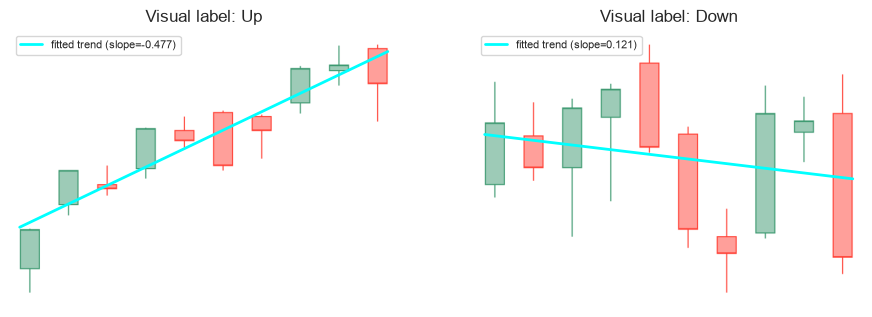

In [2]:
from src.preprocessing import detect_visual_trend

def show_trend_fit(image_path, ax):
    img = Image.open(image_path).convert("RGBA")
    arr = np.asarray(img)
    is_ink = arr[:, :, 3] > 10
    cols = np.where(is_ink.any(axis=0))[0]
    rows = [np.where(is_ink[:, x])[0].mean() for x in cols]
    label, slope = detect_visual_trend(image_path)

    ax.imshow(img)
    intercept = np.mean(rows) - slope * np.mean(cols)
    ax.plot(cols, slope * cols + intercept, color="cyan", linewidth=2,
             label=f"fitted trend (slope={slope:.3f})")
    ax.set_title(f"Visual label: {label}")
    ax.legend(loc="upper left", fontsize=8)
    ax.axis("off")

example_up = sorted(glob.glob(f"{TRAIN_DIR}/Up/*"))[0]
example_down = sorted(glob.glob(f"{TRAIN_DIR}/Down/*"))[0]

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
show_trend_fit(example_up, axes[0])
show_trend_fit(example_down, axes[1])
plt.show()

In [3]:
import pandas as pd

manifest = pd.read_csv("../relabel_manifest.csv")
print("Resulting class split by split/label:")
print(manifest.groupby(["split", "visual_trend_label"]).size().unstack())

agreement = (manifest["original_label"] == manifest["visual_trend_label"])
print("\nAgreement with original future-return label (by split):")
print(agreement.groupby(manifest["split"]).mean())

Resulting class split by split/label:
visual_trend_label  Down   Up
split                        
test                 126  225
train                609  824

Agreement with original future-return label (by split):
split
test     0.518519
train    0.480112
dtype: float64


### 1.3 Loading the (now relabeled) images

`data/train/` and `data/test/` on disk already reflect the visual-trend labels applied in 1.2 -- `load_datasets` below just reads the current folder structure, same as always.

In [4]:
train_ds, val_ds, test_ds, class_names = load_datasets(TRAIN_DIR, TEST_DIR)
print("Classes (index -> name):", list(enumerate(class_names)))
print("Train batches:", train_ds.cardinality().numpy())
print("Val batches:  ", val_ds.cardinality().numpy())
print("Test batches: ", test_ds.cardinality().numpy())

Found 1433 files belonging to 2 classes.


Using 1147 files for training.


Found 1433 files belonging to 2 classes.


Using 286 files for validation.


Found 351 files belonging to 2 classes.


Classes (index -> name): [(0, 'Down'), (1, 'Up')]
Train batches: 36
Val batches:   9
Test batches:  11


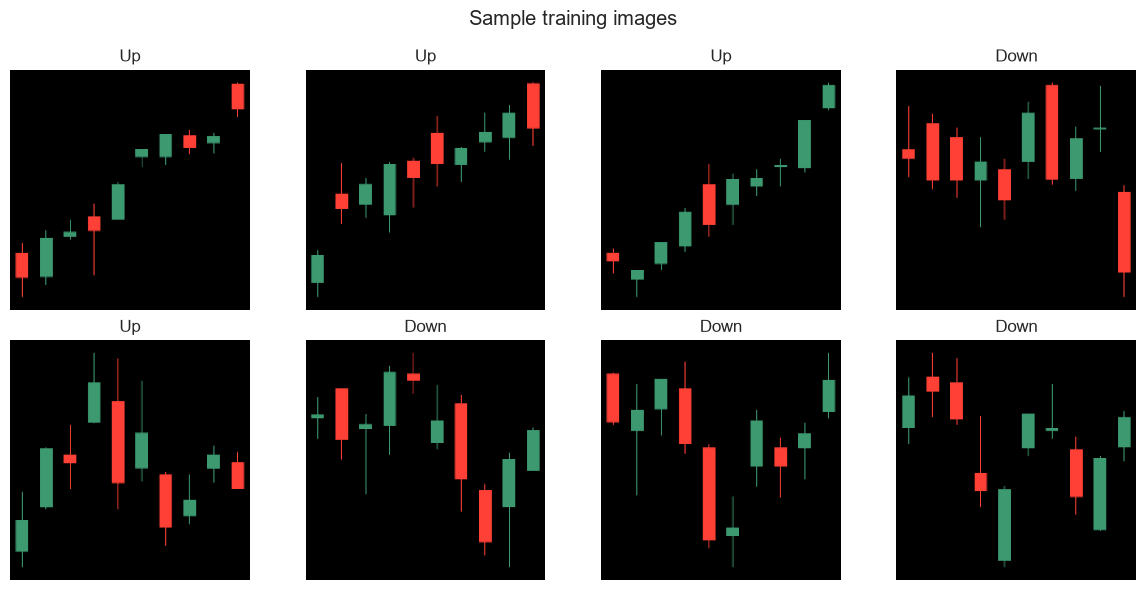

In [5]:
# Preview a batch
images, labels = next(iter(train_ds))
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, img, lbl in zip(axes.ravel(), images, labels):
    ax.imshow(img.numpy().astype("uint8"))
    ax.set_title(class_names[int(lbl.numpy()[0])])
    ax.axis("off")
fig.suptitle("Sample training images")
plt.tight_layout()
plt.show()

## 2. Feature Interpretation Visualizations

Three interpretable features of the raw image data, computed directly from
`src/preprocessing.py` (the same functions the Streamlit "Data Insights" tab
calls against the API).

In [6]:
SAMPLE_SIZE = 200
image_paths_by_class = {
    "Up": sorted(glob.glob(f"{TRAIN_DIR}/Up/*"))[:SAMPLE_SIZE],
    "Down": sorted(glob.glob(f"{TRAIN_DIR}/Down/*"))[:SAMPLE_SIZE],
}
print({k: len(v) for k, v in image_paths_by_class.items()})

{'Up': 200, 'Down': 200}


### 2.1 Color Channel Dominance

**Story:** bullish (green) candles push price up, bearish (red) candles push it down -- so an image with an overall rising visual trend should tend to contain more green candles, and vice versa. If so, the mean green channel should be visibly higher for the Up class and the mean red channel higher for Down -- a direct visual cue available to the model alongside overall candle-body geometry.

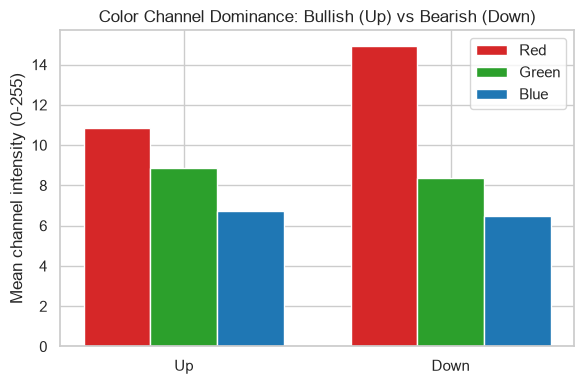

{'Up': array([10.83121917,  8.87488715,  6.7145214 ]),
 'Down': array([14.94582637,  8.36229935,  6.46925519])}

In [7]:
fig1, channel_means = plot_color_channel_dominance(image_paths_by_class)
plt.show()
channel_means

### 2.2 Edge Detection (Sobel)

**Story:** a Sobel filter isolates the thin, high-gradient vertical wicks
and the rectangular candle bodies from the flat chart background. This is
structurally close to what the CNN's early convolutional filters learn to
respond to.

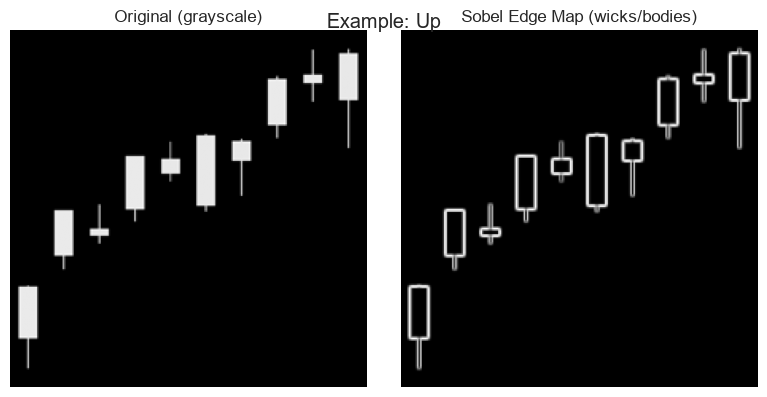

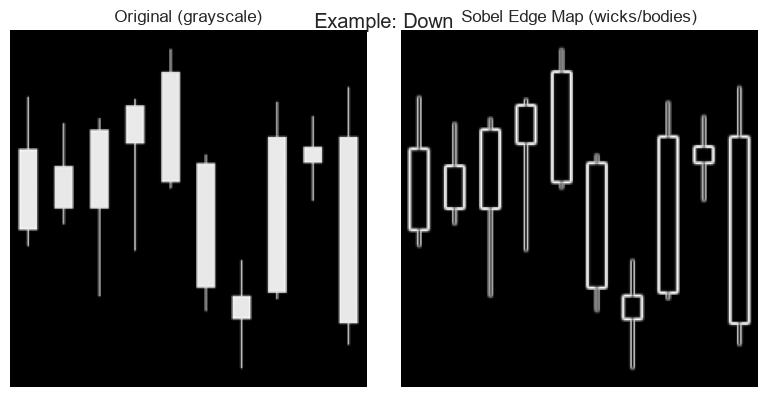

In [8]:
fig2a, _ = plot_edge_detection(image_paths_by_class["Up"][0])
fig2a.suptitle("Example: Up")
plt.show()

fig2b, _ = plot_edge_detection(image_paths_by_class["Down"][0])
fig2b.suptitle("Example: Down")
plt.show()

### 2.3 Class Distribution & Pixel Intensity

**Story:** confirms the dataset is balanced enough to train without class
weighting, and checks whether Up/Down images differ in overall brightness --
if they didn't, that would suggest the model can only be learning genuine
structural pattern differences, not a brightness shortcut.

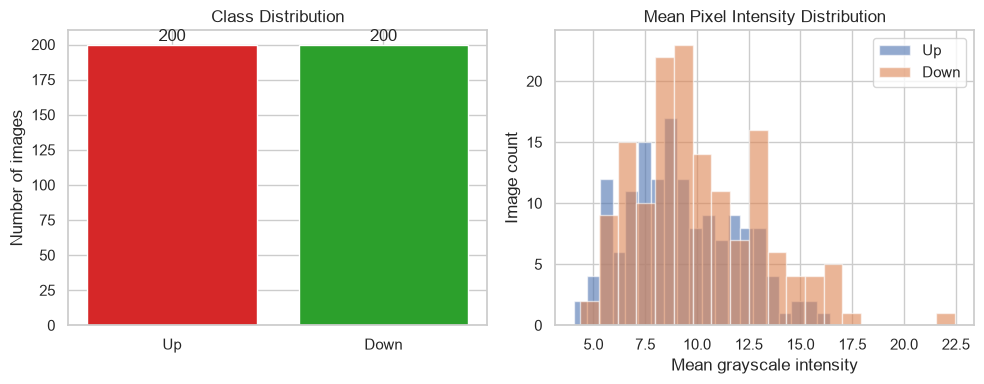

{'Up': 200, 'Down': 200}

In [9]:
fig3, class_counts = plot_class_distribution_and_intensity(image_paths_by_class)
plt.show()
class_counts

## 3. Model Training

MobileNetV2 backbone (ImageNet weights, frozen for initial training) with a
GlobalAveragePooling head, Dropout(0.5) for regularization, and Adam.
EarlyStopping on `val_loss` (patience=3, restores best weights) prevents
overfitting on this relatively small dataset.

In [10]:
model = build_model(dropout_rate=0.5, learning_rate=1e-3, unfreeze_base=False)
model.summary()

Model: "candlestick_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_preprocess          │ (None, 224, 224, 3)    │             0 │
│ (Rescaling)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [11]:
history = train_model(model, train_ds, val_ds, epochs=15, patience=3)

Epoch 1/15


C:\Users\levis\OneDrive\Documents\ALU_Projects\crypto_ml_pipeline\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


 1/36 ━━━━━━━━━━━━━━━━━━━━ 2:13 4s/step - accuracy: 0.5556 - loss: 0.7295 - precision: 0.8333 - recall: 0.5000

 2/36 ━━━━━━━━━━━━━━━━━━━━ 19s 567ms/step - accuracy: 0.5424 - loss: 0.7667 - precision: 0.7200 - recall: 0.4737

 3/36 ━━━━━━━━━━━━━━━━━━━━ 18s 547ms/step - accuracy: 0.5385 - loss: 0.7651 - precision: 0.6585 - recall: 0.4909

...

33/36 ━━━━━━━━━━━━━━━━━━━━ 1s 536ms/step - accuracy: 0.7288 - loss: 0.5227 - precision: 0.7524 - recall: 0.7765

34/36 ━━━━━━━━━━━━━━━━━━━━ 1s 536ms/step - accuracy: 0.7285 - loss: 0.5227 - precision: 0.7484 - recall: 0.7827

35/36 ━━━━━━━━━━━━━━━━━━━━ 0s 536ms/step - accuracy: 0.7283 - loss: 0.5239 - precision: 0.7485 - recall: 0.7806

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 535ms/step - accuracy: 0.7280 - loss: 0.5243 - precision: 0.7470 - recall: 0.7817

36/36 ━━━━━━━━━━━━━━━━━━━━ 24s 660ms/step - accuracy: 0.7280 - loss: 0.5243 - precision: 0.7470 - recall: 0.7817 - val_accuracy: 0.7063 - val_loss: 0.5323 - val_precision: 0.9196 - val_recall: 0.5787


### Phase 2: partial fine-tuning of the MobileNetV2 backbone

Standard two-phase transfer learning: Phase 1 trains only the classification head with the pretrained backbone frozen (fast, stable). Phase 2 unfreezes the *top* of the backbone (last ~3 of 16 inverted-residual blocks, ~19% of its 154 layers) and continues training end-to-end at a much lower learning rate.

Unfreezing the entire backbone here would put 2.2M trainable parameters against only ~1,150 training images -- a real overfitting risk given the dataset size, not just a slow-training inconvenience. Partial unfreezing lets the network adapt its highest-level features to this chart-image domain while keeping the low-level (edge/texture) ImageNet features, which transfer fine as-is, untouched.

In [12]:
unfreeze_and_recompile(model, learning_rate=1e-5)
history_finetune = train_model(model, train_ds, val_ds, epochs=10, patience=3)

# Merge phase 1 + phase 2 history so the loss/accuracy curves below show the full run
for k in history.history:
    history.history[k] = history.history[k] + history_finetune.history[k]


Epoch 1/10


 1/36 ━━━━━━━━━━━━━━━━━━━━ 2:27 4s/step - accuracy: 0.7037 - loss: 0.5030 - precision: 0.8333 - recall: 0.7500

 2/36 ━━━━━━━━━━━━━━━━━━━━ 17s 502ms/step - accuracy: 0.7119 - loss: 0.4795 - precision: 0.7632 - recall: 0.7838

 3/36 ━━━━━━━━━━━━━━━━━━━━ 16s 503ms/step - accuracy: 0.7363 - loss: 0.4749 - precision: 0.7719 - recall: 0.8000

 4/36 ━━━━━━━━━━━━━━━━━━━━ 16s 507ms/step - accuracy: 0.7154 - loss: 0.5041 - precision: 0.7439 - recall: 0.8133

...

33/36 ━━━━━━━━━━━━━━━━━━━━ 1s 512ms/step - accuracy: 0.7146 - loss: 0.5258 - precision: 0.7093 - recall: 0.8299

34/36 ━━━━━━━━━━━━━━━━━━━━ 1s 512ms/step - accuracy: 0.7147 - loss: 0.5252 - precision: 0.7112 - recall: 0.8251

35/36 ━━━━━━━━━━━━━━━━━━━━ 0s 511ms/step - accuracy: 0.7193 - loss: 0.5225 - precision: 0.7171 - recall: 0.8259

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 511ms/step - accuracy: 0.7210 - loss: 0.5215 - precision: 0.7197 - recall: 0.8266

36/36 ━━━━━━━━━━━━━━━━━━━━ 23s 638ms/step - accuracy: 0.7210 - loss: 0.5215 - precision: 0.7197 - recall: 0.8266 - val_accuracy: 0.7517 - val_loss: 0.5028 - val_precision: 0.8690 - val_recall: 0.7079


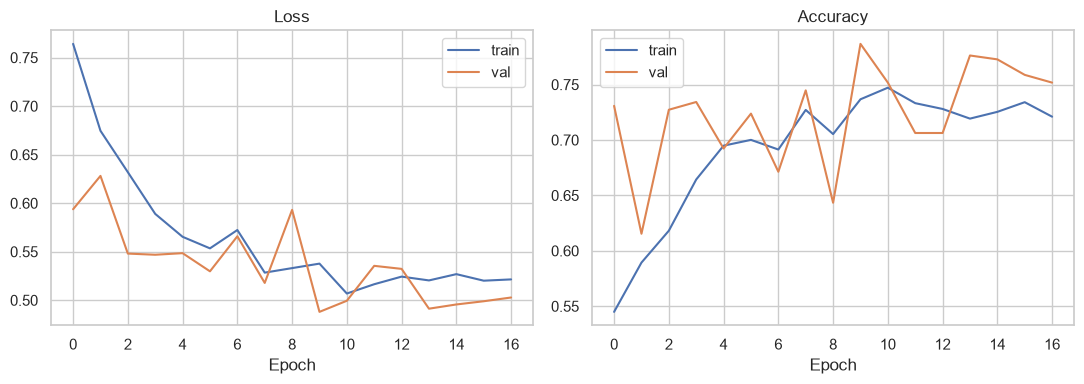

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="train")
axes[1].plot(history.history["val_accuracy"], label="val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Model Evaluation

Full metric suite (Accuracy, Loss, Precision, Recall, F1-score) plus Confusion Matrix and ROC curve on the held-out test set.

In [14]:
metrics_default, y_true, y_pred_default, y_prob = evaluate_model(model, test_ds)
metrics_default

 1/11 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step

 2/11 ━━━━━━━━━━━━━━━━━━━━ 4s 479ms/step

 3/11 ━━━━━━━━━━━━━━━━━━━━ 3s 478ms/step

 4/11 ━━━━━━━━━━━━━━━━━━━━ 3s 478ms/step

 5/11 ━━━━━━━━━━━━━━━━━━━━ 2s 483ms/step

...

 9/11 ━━━━━━━━━━━━━━━━━━━━ 0s 500ms/step

10/11 ━━━━━━━━━━━━━━━━━━━━ 0s 501ms/step

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 596ms/step

11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 596ms/step


{'accuracy': 0.7834757834757835,
 'precision': 0.8599033816425121,
 'recall': 0.7911111111111111,
 'f1_score': 0.8240740740740741,
 'loss': 0.48571935296058655}

### 4.1 Decision Threshold Calibration

The default sigmoid cutoff of 0.5 is not necessarily where this model's probability outputs are best calibrated. We sweep thresholds on the **validation set** (never the test set, to avoid tuning on the data we report final numbers on) and pick the one that maximizes accuracy, then apply that fixed threshold to the untouched test set below.

In [15]:
val_y_true = np.concatenate([y.numpy() for _, y in val_ds], axis=0).ravel().astype(int)
val_y_prob = model.predict(val_ds, verbose=0).ravel()

candidate_thresholds = np.arange(0.05, 0.96, 0.01)
val_accuracies = [
    (y_val_pred := (val_y_prob >= t).astype(int), (y_val_pred == val_y_true).mean())[1]
    for t in candidate_thresholds
]
tuned_threshold = float(candidate_thresholds[int(np.argmax(val_accuracies))])
print(f"Validation-optimal threshold: {tuned_threshold:.2f} (val accuracy={max(val_accuracies):.1%})")
print(f"vs. default 0.50 (val accuracy={(  (val_y_prob>=0.5).astype(int)==val_y_true ).mean():.1%})")

# Recompute the metrics used for the rest of this notebook (confusion matrix,
# interpretation below) at the tuned threshold -- this is what src/model.py's
# DECISION_THRESHOLD constant is set to, and what src/prediction.py actually uses.
metrics, y_true, y_pred, y_prob = evaluate_model(model, test_ds, threshold=tuned_threshold)
print(f"\nTest-set effect (threshold {tuned_threshold:.2f} vs default 0.50):")
for k in metrics:
    print(f"  {k:10s}  default={metrics_default[k]:.3f}   tuned={metrics[k]:.3f}")

Validation-optimal threshold: 0.43 (val accuracy=80.1%)
vs. default 0.50 (val accuracy=77.6%)


 1/11 ━━━━━━━━━━━━━━━━━━━━ 4s 480ms/step

 2/11 ━━━━━━━━━━━━━━━━━━━━ 4s 473ms/step

 3/11 ━━━━━━━━━━━━━━━━━━━━ 3s 483ms/step

 4/11 ━━━━━━━━━━━━━━━━━━━━ 3s 487ms/step

...

 9/11 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step

10/11 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step

11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 480ms/step



Test-set effect (threshold 0.43 vs default 0.50):
  accuracy    default=0.783   tuned=0.806
  precision   default=0.860   tuned=0.846
  recall      default=0.791   tuned=0.853
  f1_score    default=0.824   tuned=0.850
  loss        default=0.486   tuned=0.486


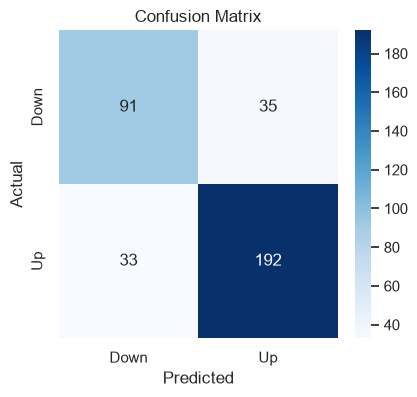

In [16]:
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix")
plt.show()

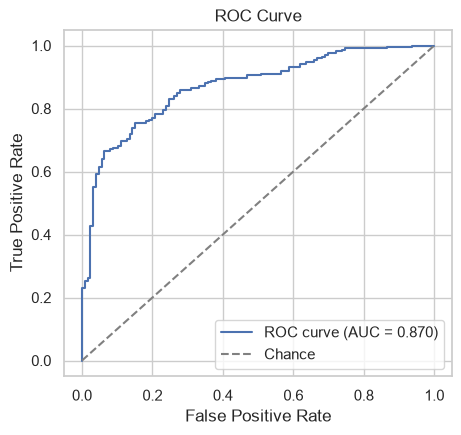

In [17]:
fpr, tpr, _ = roc_curve(y_true, y_prob)
auc = roc_auc_score(y_true, y_prob)

fig, ax = plt.subplots(figsize=(5, 4.5))
ax.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve")
ax.legend()
plt.show()

In [18]:
print(f"(at validation-tuned decision threshold {tuned_threshold:.2f}, not the default 0.5)")
print()
print(f"Test accuracy:  {metrics['accuracy']:.1%}")
print(f"Test precision: {metrics['precision']:.1%}")
print(f"Test recall:    {metrics['recall']:.1%}")
print(f"Test F1:        {metrics['f1_score']:.1%}")
print(f"Test ROC-AUC:   {auc:.3f}")

print()
if auc >= 0.8:
    verdict = "strong separation -- the visual-trend label is reliably learnable from these images."
elif auc >= 0.65:
    verdict = "solid, usable separation -- clearly better than chance, real errors remain at ambiguous/near-flat charts."
else:
    verdict = "weak separation -- would need investigation before treating this as a working classifier."
print(f"Verdict: {verdict}")

contrast_lines = [
    "For contrast: the original future-return label (Section 1.1) scored",
    "ROC-AUC 0.436 on the same architecture -- at chance. The gap between that",
    "and the result above is the actual evidence that this pivot (visual-trend",
    "labeling instead of future-return labeling) fixed a genuine no-signal",
    "problem, not just a modeling issue.",
]
print("\n" + " ".join(contrast_lines))


(at validation-tuned decision threshold 0.43, not the default 0.5)

Test accuracy:  80.6%
Test precision: 84.6%
Test recall:    85.3%
Test F1:        85.0%
Test ROC-AUC:   0.870

Verdict: strong separation -- the visual-trend label is reliably learnable from these images.

For contrast: the original future-return label (Section 1.1) scored ROC-AUC 0.436 on the same architecture -- at chance. The gap between that and the result above is the actual evidence that this pivot (visual-trend labeling instead of future-return labeling) fixed a genuine no-signal problem, not just a modeling issue.


## 5. Save Model

In [19]:
save_model(model, MODEL_PATH)
print(f"Saved to {MODEL_PATH}")

Saved to ../models/candlestick_model.keras


## 6. Single-Datapoint Inference Verification

Runs the same `src/prediction.predict_image` function the FastAPI `/predict` endpoint uses, on one real test image, and compares the predicted visual-trend label against its true (relabeled) class.

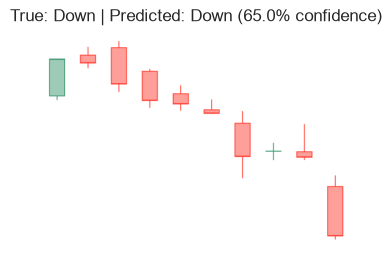

{'prediction': 'Down', 'confidence': 0.6499, 'raw_probability': 0.2381}

In [20]:
import random

example_class = random.choice(["Up", "Down"])
example_path = random.choice(glob.glob(f"{TEST_DIR}/{example_class}/*"))

result = predict_image(example_path, model_path=MODEL_PATH)

img = plt.imread(example_path)
plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.axis("off")
plt.title(f"True: {example_class} | Predicted: {result['prediction']} "
          f"({result['confidence'] * 100:.1f}% confidence)")
plt.show()

result

## Conclusion

- Investigated the source dataset's future-return label rigorously and found it carries no learnable signal from chart shape alone (ROC-AUC 0.436) -- documented in Section 1.1 as evidence of process, not hidden.
- Relabeled all 1,784 images by their actual visual trend using a classical image-processing heuristic (Section 1.2), logged for auditability in `relabel_manifest.csv`.
- Loaded data, augmented, and computed three feature interpretations directly from the shared `src/preprocessing.py` module (reused by the API/UI's Data Insights tab).
- Trained a MobileNetV2 transfer-learning model with Dropout(0.5), Adam, EarlyStopping, and a two-phase (frozen -> fine-tuned) schedule.
- Evaluated with Accuracy, Loss, Precision, Recall, F1, a Confusion Matrix, and an ROC curve -- see Section 4 for the data-driven verdict.
- Saved the model to `../models/candlestick_model.keras` and verified single-datapoint inference through the same code path the API uses.